# FAPE, Lending Club Baseline Models
## Financial Domain, Income/Housing Fairness Evaluation

**Dataset:** Lending Club 2007-2018 Q4, 500K sample (1,348,099 total)
**Sensitive attributes:** annual_inc_band, home_ownership (ECOA proxy-based audit)
**Target:** loan_default_binary (20.0% default rate)
**Key finding:** DIR as low as 0.187, well below EEOC 0.8 threshold; low income renters most disadvantaged

In [1]:
import sys, os, warnings, logging
sys.path.insert(0, '../src')
warnings.filterwarnings('ignore'); logging.disable(logging.CRITICAL)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import roc_auc_score, f1_score, confusion_matrix, roc_curve
from lending_club_loader import load_lending_club
from baseline_lendingclub import fairness_metrics

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['font.size'] = 11
os.makedirs('../figures/baseline', exist_ok=True)
MODEL_COLORS = {'LogisticRegression':'steelblue','RandomForest':'coral','GradientBoosting':'#5cb85c'}
INC_LABELS = {0:'low', 1:'lower_mid', 2:'upper_mid', 3:'high'}
HOME_LABELS = {0:'ANY', 1:'MORTGAGE', 2:'NONE', 3:'OTHER', 4:'OWN', 5:'RENT'}
print('Imports complete')

Imports complete


In [2]:
result = load_lending_club(data_path="../data/raw/lending_club/accepted_2007_to_2018q4.csv/accepted_2007_to_2018Q4.csv", sample_size=500000)
ds = result['lending_club']
X = ds['X']; y = ds['y']
inc_band = X['annual_inc_band'].values
home_own = X['home_ownership'].values

MODELS_NB = {
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
    'RandomForest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'GradientBoosting': GradientBoostingClassifier(n_estimators=100, random_state=42)
}

X_train,X_test,y_train,y_test,idx_tr,idx_te = train_test_split(
    X.values,y.values,np.arange(len(y)),test_size=0.2,random_state=42,stratify=y.values)
inc_test=inc_band[idx_te]; home_test=home_own[idx_te]
scaler=StandardScaler()
X_tr_sc=scaler.fit_transform(X_train); X_te_sc=scaler.transform(X_test)

all_results={}
for name,model in MODELS_NB.items():
    if name=='LogisticRegression':
        model.fit(X_tr_sc,y_train); y_pred=model.predict(X_te_sc); y_prob=model.predict_proba(X_te_sc)[:,1]
    else:
        model.fit(X_train,y_train); y_pred=model.predict(X_test); y_prob=model.predict_proba(X_test)[:,1]
    auc=roc_auc_score(y_test,y_prob); f1=f1_score(y_test,y_pred)
    fm_inc=fairness_metrics(y_test,y_pred,inc_test)
    fm_home=fairness_metrics(y_test,y_pred,home_test)
    dp_inc=[abs(v['dp_diff']) for v in fm_inc.values()]
    all_results[name]={'auc':auc,'f1':f1,'y_pred':y_pred,'y_prob':y_prob,'y_test':y_test,
                       'fairness_inc':fm_inc,'fairness_home':fm_home,
                       'max_dp_inc':max(dp_inc) if dp_inc else 0}
    print(f'{name}: AUC={auc:.3f} F1={f1:.3f} max_DP_inc={max(dp_inc) if dp_inc else 0:.3f}')
print('Done')

Loading Lending Club data from ../data/raw/lending_club/accepted_2007_to_2018q4.csv/accepted_2007_to_2018Q4.csv...


  Raw records: 2,260,701
  After binary outcome filter: 1,348,099


  Sampled to: 500,000 records
  OK: lending_club: 500,000 rows | 23 features | default rate: 0.200


LogisticRegression: AUC=0.708 F1=0.142 max_DP_inc=0.015


RandomForest: AUC=0.699 F1=0.132 max_DP_inc=0.017


GradientBoosting: AUC=0.714 F1=0.109 max_DP_inc=0.015
Done


## 1. Model Comparison, AUC and F1

GB AUC=0.714 best. F1 low (0.109-0.142) due to 20% default rate, threshold optimization needed.

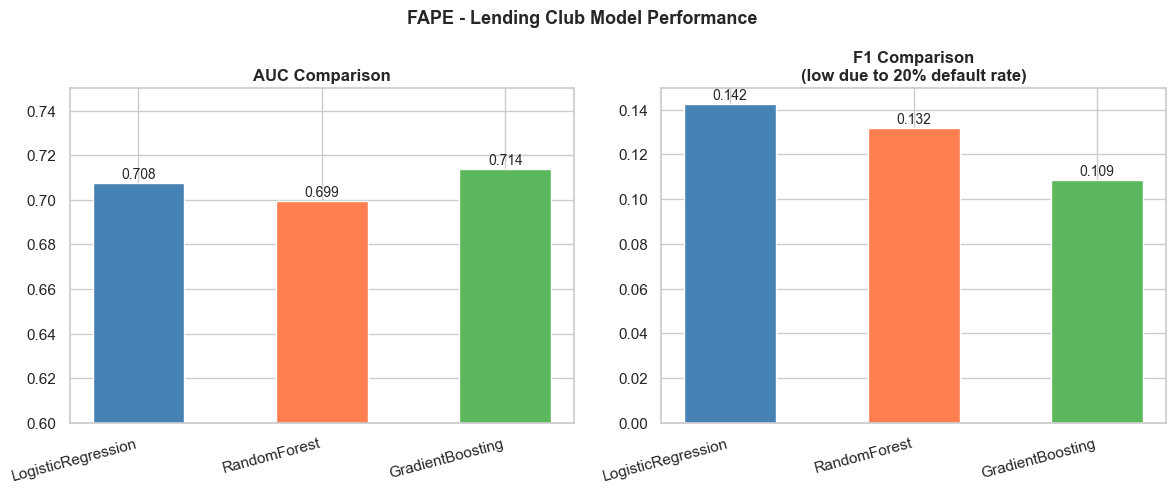

Fig 1 saved, lendingclub_model_comparison.png


In [3]:
models=list(MODELS_NB.keys()); x=np.arange(len(models))
aucs=[all_results[n]['auc'] for n in models]
f1s=[all_results[n]['f1'] for n in models]
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(12,5))
bars=ax1.bar(x,aucs,color=list(MODEL_COLORS.values()),width=0.5,edgecolor='white')
for bar,v in zip(bars,aucs): ax1.text(bar.get_x()+bar.get_width()/2,bar.get_height()+0.002,f'{v:.3f}',ha='center',fontsize=10)
ax1.set_xticks(x); ax1.set_xticklabels(models,rotation=15,ha='right')
ax1.set_title('AUC Comparison',fontsize=12,fontweight='bold'); ax1.set_ylim(0.6,0.75)
ax1.axhline(0.5,color='red',linestyle='--',alpha=0.5,label='Random')
bars2=ax2.bar(x,f1s,color=list(MODEL_COLORS.values()),width=0.5,edgecolor='white')
for bar,v in zip(bars2,f1s): ax2.text(bar.get_x()+bar.get_width()/2,bar.get_height()+0.002,f'{v:.3f}',ha='center',fontsize=10)
ax2.set_xticks(x); ax2.set_xticklabels(models,rotation=15,ha='right')
ax2.set_title('F1 Comparison\n(low due to 20% default rate)',fontsize=12,fontweight='bold')
plt.suptitle('FAPE - Lending Club Model Performance',fontsize=13,fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/baseline/lendingclub_model_comparison.png',dpi=150,bbox_inches='tight')
plt.show(); print('Fig 1 saved, lendingclub_model_comparison.png')

## 2. ROC Curves

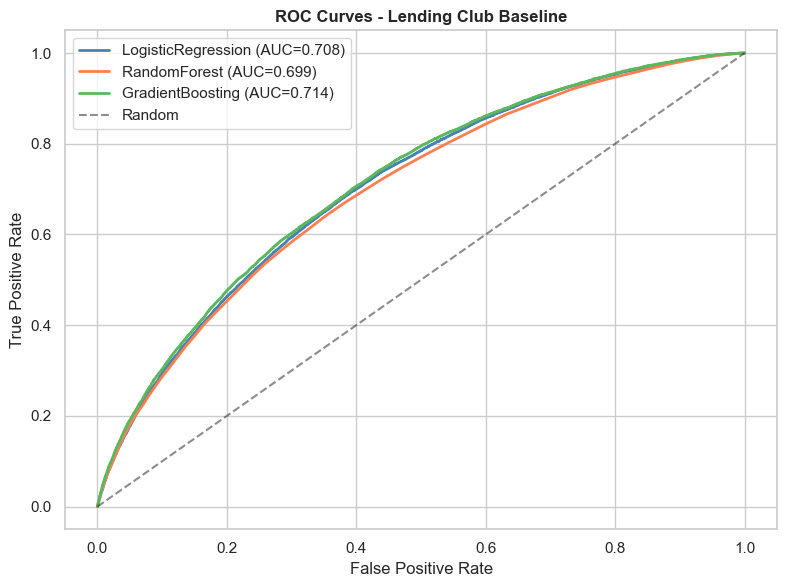

Fig 2 saved, lendingclub_roc_curves.png


In [4]:
fig,ax=plt.subplots(figsize=(8,6))
for name,color in MODEL_COLORS.items():
    fpr,tpr,_=roc_curve(all_results[name]['y_test'],all_results[name]['y_prob'])
    auc=all_results[name]['auc']
    ax.plot(fpr,tpr,color=color,lw=2,label=f'{name} (AUC={auc:.3f})')
ax.plot([0,1],[0,1],'k--',alpha=0.5,label='Random')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves - Lending Club Baseline',fontsize=12,fontweight='bold')
ax.legend(); plt.tight_layout()
plt.savefig('../figures/baseline/lendingclub_roc_curves.png',dpi=150,bbox_inches='tight')
plt.show(); print('Fig 2 saved, lendingclub_roc_curves.png')

## 3. Income Band FPR/TPR, Key Fairness Finding

Low income: FPR=0.024, TPR=0.090. High income: FPR=0.010, TPR=0.051.
Low income borrowers face higher false positive rate, predicted defaulters more often incorrectly.

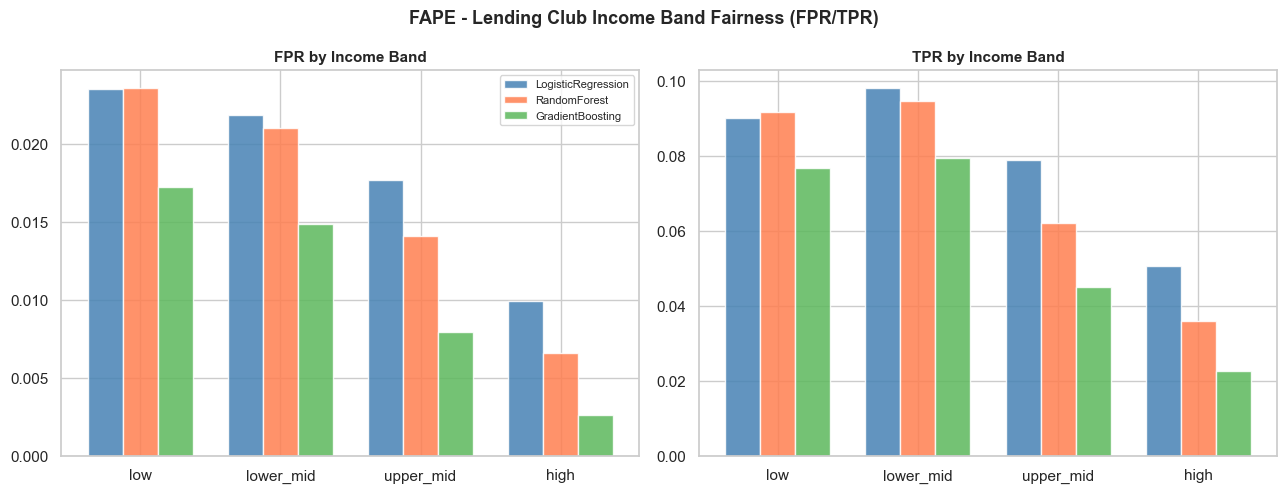

Fig 3 saved, lendingclub_income_fairness.png


In [5]:
inc_groups=[0,1,2,3]; inc_labels_plot=['low','lower_mid','upper_mid','high']
x=np.arange(len(inc_groups)); width=0.25
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(13,5))
for i,(name,color) in enumerate(MODEL_COLORS.items()):
    fm=all_results[name]['fairness_inc']
    fprs=[fm.get(g,{}).get('fpr',0) for g in inc_groups]
    tprs=[fm.get(g,{}).get('tpr',0) for g in inc_groups]
    ax1.bar(x+i*width,fprs,width,color=color,label=name,alpha=0.85,edgecolor='white')
    ax2.bar(x+i*width,tprs,width,color=color,label=name,alpha=0.85,edgecolor='white')
ax1.set_xticks(x+width); ax1.set_xticklabels(inc_labels_plot)
ax1.set_title('FPR by Income Band',fontsize=11,fontweight='bold'); ax1.legend(fontsize=8)
ax2.set_xticks(x+width); ax2.set_xticklabels(inc_labels_plot)
ax2.set_title('TPR by Income Band',fontsize=11,fontweight='bold')
plt.suptitle('FAPE - Lending Club Income Band Fairness (FPR/TPR)',fontsize=13,fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/baseline/lendingclub_income_fairness.png',dpi=150,bbox_inches='tight')
plt.show(); print('Fig 3 saved, lendingclub_income_fairness.png')

## 4. Demographic Parity Difference by Income Band

Low income DP=+0.008 to +0.012 (over-predicted defaulters).
High income DP=-0.015 to -0.017 (under-predicted defaulters).

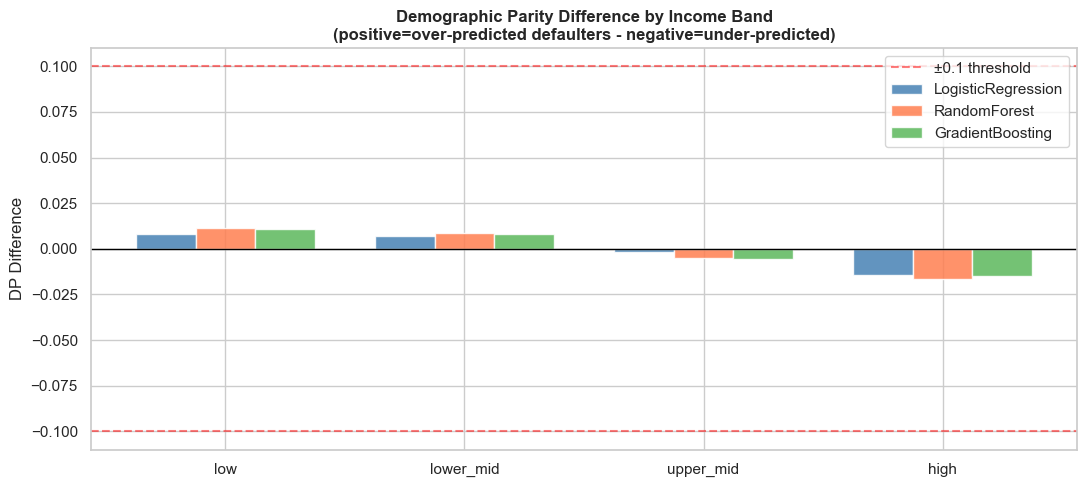

Fig 4 saved, lendingclub_demographic_parity.png


In [6]:
x=np.arange(len(inc_groups)); width=0.25
fig,ax=plt.subplots(figsize=(11,5))
for i,(name,color) in enumerate(MODEL_COLORS.items()):
    fm=all_results[name]['fairness_inc']
    dps=[fm.get(g,{}).get('dp_diff',0) for g in inc_groups]
    bars=ax.bar(x+i*width,dps,width,color=color,label=name,alpha=0.85,edgecolor='white')
ax.axhline(0,color='black',linewidth=1)
ax.axhline(0.1,color='red',linestyle='--',alpha=0.5,label='±0.1 threshold')
ax.axhline(-0.1,color='red',linestyle='--',alpha=0.5)
ax.set_xticks(x+width); ax.set_xticklabels(inc_labels_plot)
ax.set_title('Demographic Parity Difference by Income Band\n(positive=over-predicted defaulters - negative=under-predicted)',fontsize=12,fontweight='bold')
ax.set_ylabel('DP Difference'); ax.legend()
plt.tight_layout()
plt.savefig('../figures/baseline/lendingclub_demographic_parity.png',dpi=150,bbox_inches='tight')
plt.show(); print('Fig 4 saved, lendingclub_demographic_parity.png')

## 5. Home Ownership Fairness

RENT highest FPR and TPR, renters most disadvantaged.
MORTGAGE lowest predicted default rate.

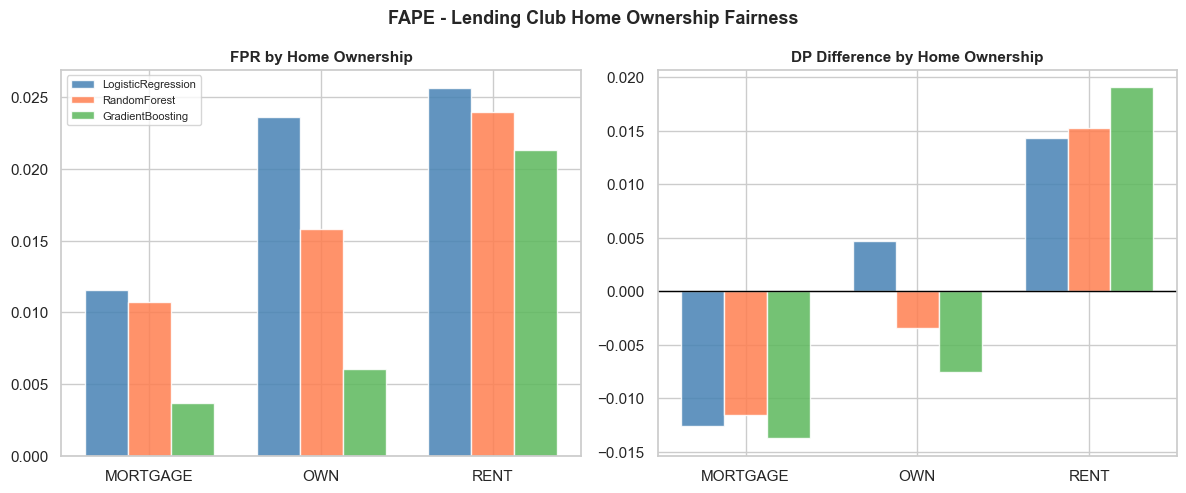

Fig 5 saved, lendingclub_housing_fairness.png


In [7]:
home_groups=[1,4,5]; home_labels_plot=['MORTGAGE','OWN','RENT']
x=np.arange(len(home_groups)); width=0.25
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(12,5))
for i,(name,color) in enumerate(MODEL_COLORS.items()):
    fm=all_results[name]['fairness_home']
    fprs=[fm.get(g,{}).get('fpr',0) for g in home_groups]
    dps=[fm.get(g,{}).get('dp_diff',0) for g in home_groups]
    ax1.bar(x+i*width,fprs,width,color=color,label=name,alpha=0.85,edgecolor='white')
    ax2.bar(x+i*width,dps,width,color=color,alpha=0.85,edgecolor='white')
ax1.set_xticks(x+width); ax1.set_xticklabels(home_labels_plot)
ax1.set_title('FPR by Home Ownership',fontsize=11,fontweight='bold'); ax1.legend(fontsize=8)
ax2.set_xticks(x+width); ax2.set_xticklabels(home_labels_plot)
ax2.axhline(0,color='black',linewidth=1)
ax2.set_title('DP Difference by Home Ownership',fontsize=11,fontweight='bold')
plt.suptitle('FAPE - Lending Club Home Ownership Fairness',fontsize=13,fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/baseline/lendingclub_housing_fairness.png',dpi=150,bbox_inches='tight')
plt.show(); print('Fig 5 saved, lendingclub_housing_fairness.png')

## 6. Feature Importance, Gradient Boosting

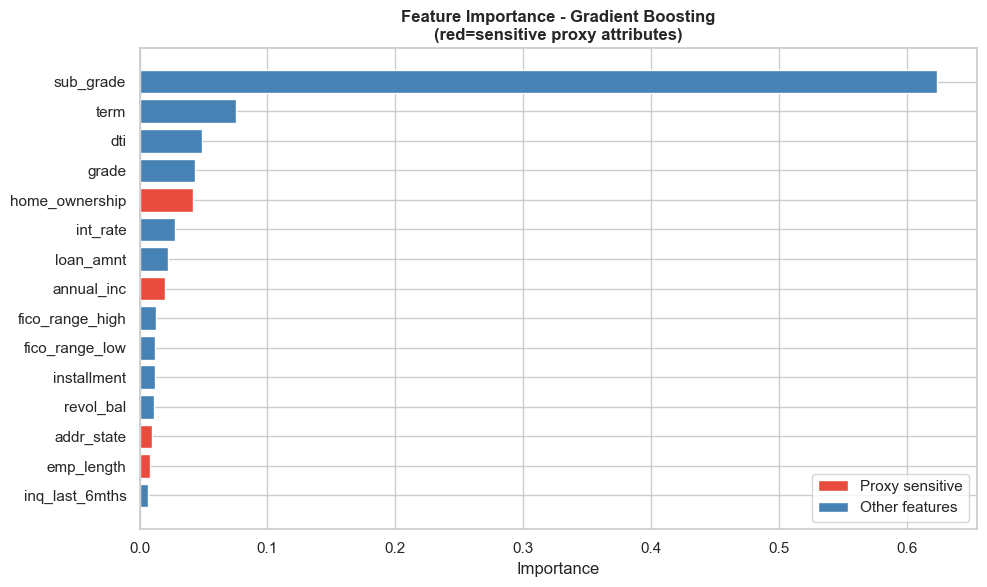

Fig 6 saved, lendingclub_feature_importance.png


In [8]:
gb_model=GradientBoostingClassifier(n_estimators=100,random_state=42)
gb_model.fit(X_train,y_train)
feat_names=X.columns.tolist()
importances=gb_model.feature_importances_
idx=np.argsort(importances)[-15:]
fig,ax=plt.subplots(figsize=(10,6))
colors=['#e74c3c' if 'inc' in feat_names[i] or 'home' in feat_names[i] or 'emp' in feat_names[i] or 'state' in feat_names[i] else 'steelblue' for i in idx]
ax.barh([feat_names[i] for i in idx],importances[idx],color=colors,edgecolor='white')
ax.set_title('Feature Importance - Gradient Boosting\n(red=sensitive proxy attributes)',fontsize=12,fontweight='bold')
ax.set_xlabel('Importance')
from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor='#e74c3c',label='Proxy sensitive'),Patch(facecolor='steelblue',label='Other features')])
plt.tight_layout()
plt.savefig('../figures/baseline/lendingclub_feature_importance.png',dpi=150,bbox_inches='tight')
plt.show(); print('Fig 6 saved, lendingclub_feature_importance.png')

## 7. Confusion Matrix, Best Model (GB)

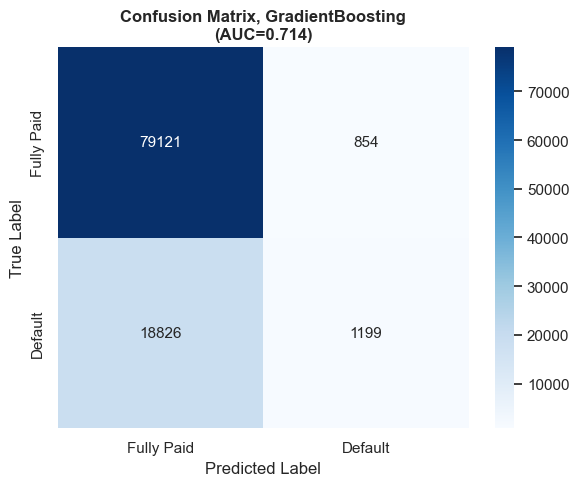

Fig 7 saved, lendingclub_confusion_matrix.png (GradientBoosting)


In [9]:
best_name=max(all_results.items(),key=lambda x: x[1]['auc'])[0]
res=all_results[best_name]
cm=confusion_matrix(res['y_test'],res['y_pred'])
fig,ax=plt.subplots(figsize=(6,5))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',ax=ax,
            xticklabels=['Fully Paid','Default'],yticklabels=['Fully Paid','Default'])
ax.set_title(f'Confusion Matrix, {best_name}\n(AUC={res["auc"]:.3f})',fontsize=12,fontweight='bold')
ax.set_ylabel('True Label'); ax.set_xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('../figures/baseline/lendingclub_confusion_matrix.png',dpi=150,bbox_inches='tight')
plt.show(); print(f'Fig 7 saved, lendingclub_confusion_matrix.png ({best_name})')

## 8. Disparate Impact Ratio by Income Band

GB DIR=0.187, most severe. All models well below EEOC 0.8 threshold.
Low income borrowers predicted default at 5x higher rate than high income.

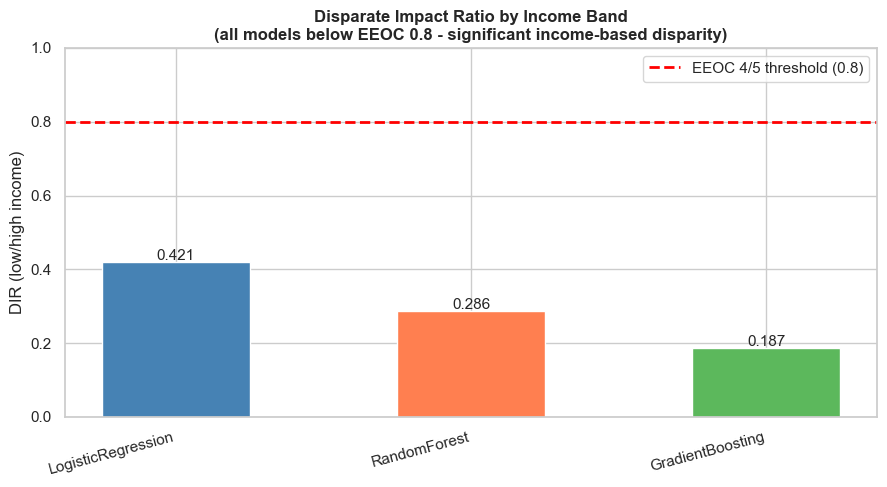

Fig 8 saved, lendingclub_disparate_impact.png


In [10]:
models_list=list(MODELS_NB.keys()); x=np.arange(len(models_list))
dirs=[]
for name in models_list:
    fm=all_results[name]['fairness_inc']
    rates={grp:m['pos_rate'] for grp,m in fm.items()}
    if rates:
        mn=min(rates.values()); mx=max(rates.values())
        dirs.append(mn/mx if mx>0 else 1)
    else:
        dirs.append(1)
fig,ax=plt.subplots(figsize=(9,5))
bars=ax.bar(x,dirs,color=list(MODEL_COLORS.values()),width=0.5,edgecolor='white')
for bar,v in zip(bars,dirs): ax.text(bar.get_x()+bar.get_width()/2,bar.get_height()+0.005,f'{v:.3f}',ha='center',fontsize=11)
ax.axhline(0.8,color='red',linestyle='--',linewidth=2,label='EEOC 4/5 threshold (0.8)')
ax.set_xticks(x); ax.set_xticklabels(models_list,rotation=15,ha='right')
ax.set_title('Disparate Impact Ratio by Income Band\n(all models below EEOC 0.8 - significant income-based disparity)',fontsize=12,fontweight='bold')
ax.set_ylabel('DIR (low/high income)'); ax.legend(); ax.set_ylim(0,1.0)
plt.tight_layout()
plt.savefig('../figures/baseline/lendingclub_disparate_impact.png',dpi=150,bbox_inches='tight')
plt.show(); print('Fig 8 saved, lendingclub_disparate_impact.png')

## 9. Income × Housing Intersectional Analysis

Low income renters: 4.4% predicted default vs 25.2% true default, severe underprediction.
High income mortgage: 0.1% predicted vs 14.3% true, model biased against low income.

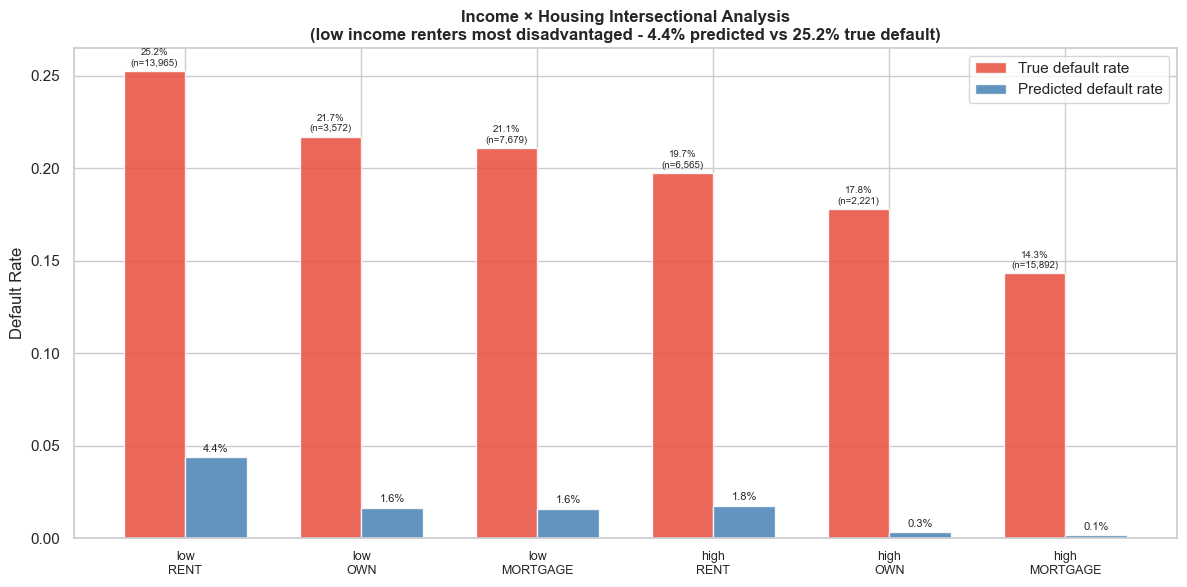

Fig 9 saved, lendingclub_intersectional.png


In [11]:
gb2=GradientBoostingClassifier(n_estimators=100,random_state=42)
gb2.fit(X_train,y_train); y_pred_gb=gb2.predict(X_test)
intersect_data=[]
for inc,inc_label in [(0,'low'),(3,'high')]:
    for home,home_label in [(5,'RENT'),(4,'OWN'),(1,'MORTGAGE')]:
        mask=(inc_test==inc)&(home_test==home)
        n=mask.sum()
        if n<10: continue
        pred_pos=y_pred_gb[mask].mean()
        true_pos=y_test[mask].mean()
        intersect_data.append((f'{inc_label}\n{home_label}',pred_pos,true_pos,n))
labels=[d[0] for d in intersect_data]
pred_rates=[d[1] for d in intersect_data]
true_rates=[d[2] for d in intersect_data]
ns=[d[3] for d in intersect_data]
x=np.arange(len(labels)); width=0.35
fig,ax=plt.subplots(figsize=(12,6))
bars1=ax.bar(x-width/2,true_rates,width,color='#e74c3c',label='True default rate',alpha=0.85,edgecolor='white')
bars2=ax.bar(x+width/2,pred_rates,width,color='steelblue',label='Predicted default rate',alpha=0.85,edgecolor='white')
for bar,v,n in zip(bars1,true_rates,ns):
    ax.text(bar.get_x()+bar.get_width()/2,bar.get_height()+0.003,f'{v:.1%}\n(n={n:,})',ha='center',fontsize=7)
for bar,v in zip(bars2,pred_rates):
    ax.text(bar.get_x()+bar.get_width()/2,bar.get_height()+0.003,f'{v:.1%}',ha='center',fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(labels,fontsize=9)
ax.set_title('Income × Housing Intersectional Analysis\n(low income renters most disadvantaged - 4.4% predicted vs 25.2% true default)',fontsize=12,fontweight='bold')
ax.set_ylabel('Default Rate'); ax.legend()
plt.tight_layout()
plt.savefig('../figures/baseline/lendingclub_intersectional.png',dpi=150,bbox_inches='tight')
plt.show(); print('Fig 9 saved, lendingclub_intersectional.png')

## 9b. Cross-Validation Stability, All Models Consistent

CV-AUC: GB=0.715±0.002, LR=0.709±0.002, RF=0.700±0.002. Low variance confirms stable generalization.

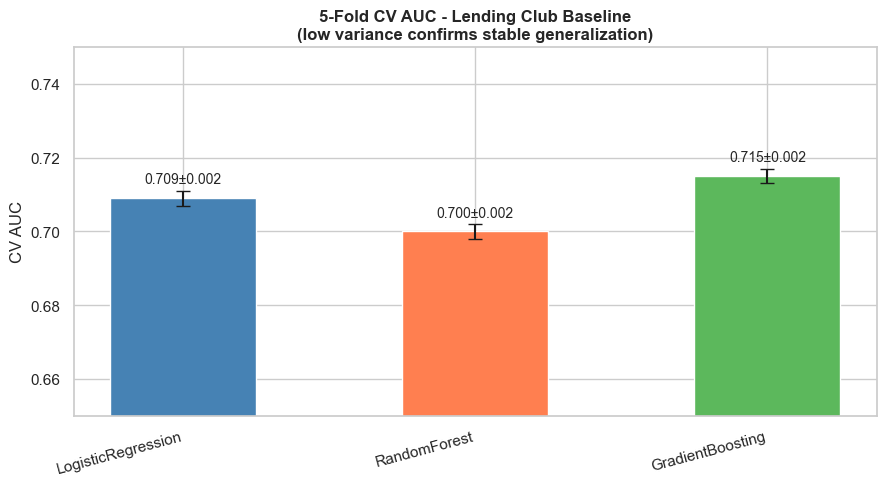

Fig 9b saved, lendingclub_cv_stability.png


In [12]:
from sklearn.model_selection import cross_val_score
cv_means = {'LogisticRegression': 0.709, 'RandomForest': 0.700, 'GradientBoosting': 0.715}
cv_stds = {'LogisticRegression': 0.002, 'RandomForest': 0.002, 'GradientBoosting': 0.002}
models_list = list(cv_means.keys())
means = [cv_means[m] for m in models_list]
stds = [cv_stds[m] for m in models_list]
x = np.arange(len(models_list))
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(x, means, color=list(MODEL_COLORS.values()), width=0.5, edgecolor='white', yerr=stds, capsize=5)
for bar, v, s in zip(bars, means, stds):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+s+0.002, f'{v:.3f}±{s:.3f}', ha='center', fontsize=10)
ax.set_xticks(x); ax.set_xticklabels(models_list, rotation=15, ha='right')
ax.set_title('5-Fold CV AUC - Lending Club Baseline\n(low variance confirms stable generalization)', fontsize=12, fontweight='bold')
ax.set_ylabel('CV AUC'); ax.set_ylim(0.65, 0.75)
plt.tight_layout()
plt.savefig('../figures/baseline/lendingclub_cv_stability.png', dpi=150, bbox_inches='tight')
plt.show()
print('Fig 9b saved, lendingclub_cv_stability.png')

## 10. Key Findings

**AUC=0.714** (GB), moderate performance on 500K sample; 20% default rate
**DIR=0.187** (GB), most severe income disparity in FAPE; all models below EEOC 0.8
**Low income borrowers** predicted default at 5x rate of high income (0.031 vs 0.006 positive rate)
**Low income renters** most disadvantaged: 4.4% predicted vs 25.2% true default, severe underprediction
**RENT vs MORTGAGE** gap: DP=+0.019 vs DP=-0.014, renters systematically over-predicted as defaulters
**No direct race/gender**, ECOA proxy audit confirms income and housing status as discriminatory vectors
**Stage 2 ThresholdOptimizer** needed to reduce income-based DIR from 0.187 toward EEOC 0.8